In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

In [20]:
df = pd.read_csv('Mall_Customers.csv')
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


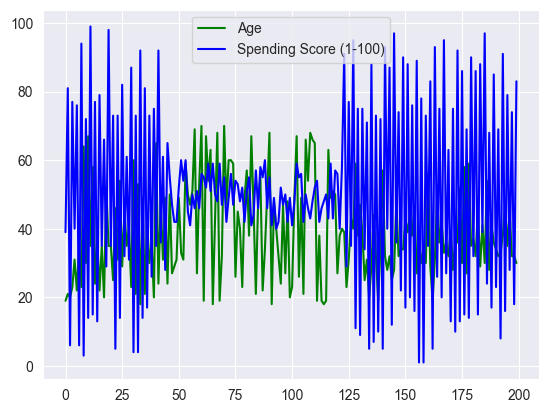

In [101]:
#Age vs Spending Score Not Scaled

plt.plot(df['Age'], label='Age', color='green')
plt.plot(df['Spending Score (1-100)'], label='Spending Score (1-100)', color='blue')
plt.legend()

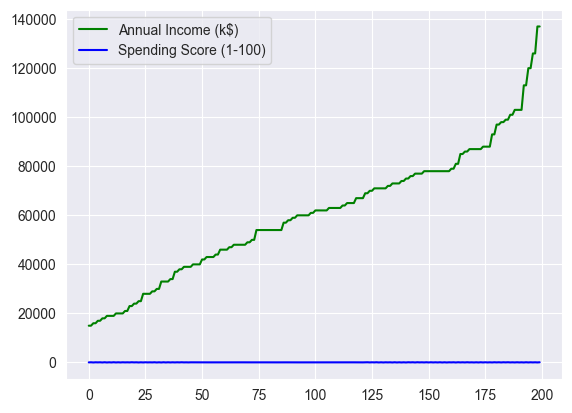

In [73]:
#Income vs Spending Score Not Scaled

plt.plot(df['Annual Income (k$)'] * 1000, label='Annual Income (k$)', color='green')
plt.plot(df['Spending Score (1-100)'], label='Spending Score (1-100)', color='blue')
plt.legend()

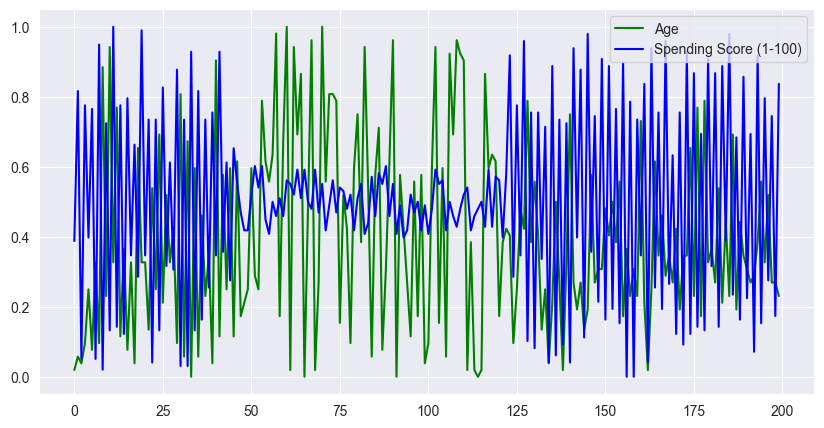

In [52]:
#Age vs Spending Score Scaled

scaler = MinMaxScaler(feature_range=(0,1))
Age_scaled = scaler.fit_transform(np.array(df['Age']).reshape(-1,1))
time_spend = scaler.fit_transform(np.array(df['Spending Score (1-100)']).reshape(-1,1))
plt.figure(figsize=(10,5))
plt.plot(Age_scaled, label='Age', color='green')
plt.plot(time_spend, label='Spending Score (1-100)', color='blue')
plt.legend()

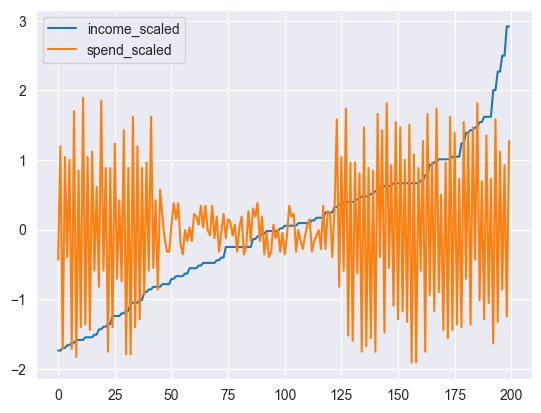

In [67]:
#Income vs Spending Score Scaled

scaler = StandardScaler()
income_scaled = scaler.fit_transform(np.array(df['Annual Income (k$)'] * 1000).reshape(-1,1))
spend_scaled = scaler.fit_transform(np.array(df['Spending Score (1-100)']).reshape(-1,1))

plt.plot(income_scaled, label='income_scaled')
plt.plot(spend_scaled, label='spend_scaled')
plt.legend()

In [100]:
df[['Age','Annual Income (k$)','Spending Score (1-100)']].corr()

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


<Axes: >

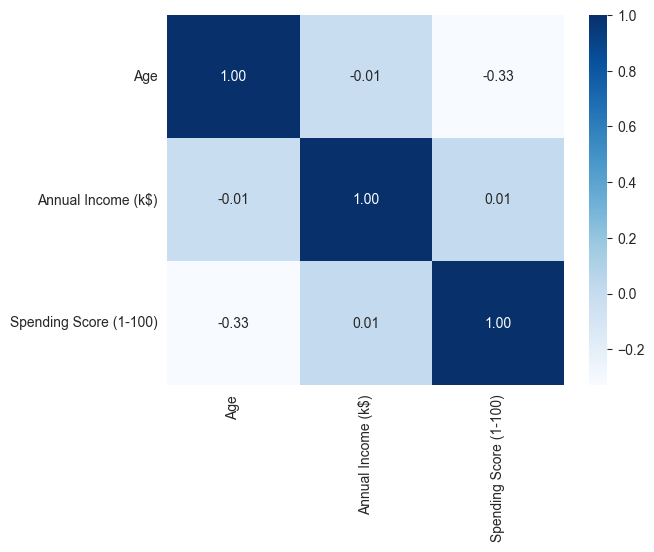

In [99]:
sns.heatmap(df[['Age','Annual Income (k$)','Spending Score (1-100)']].corr(), annot=True, fmt="0.2f", cmap="Blues")

Text(0, 0.5, 'Time spend')

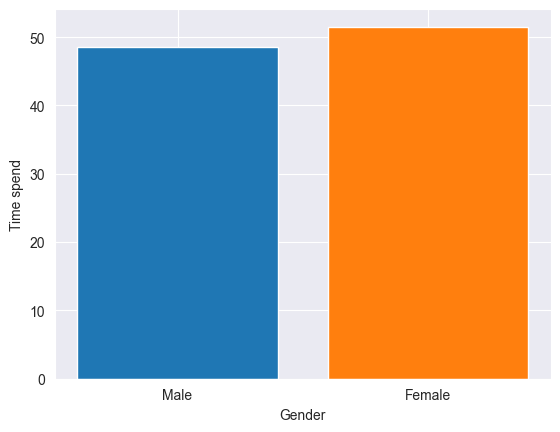

In [102]:
#Gender vs Spending Score (1-100)

plt.bar('Male',df[df['Gender'] == 'Male']['Spending Score (1-100)'].mean())
plt.bar('Female',df[df['Gender'] == 'Female']['Spending Score (1-100)'].mean())
plt.xlabel('Gender')
plt.ylabel('Time spend')